# Molecular Graph Visualisation

This notebook visualises and compares three graph representations for any molecule:

1. **Real molecular graph** — from pymatgen/molecule_graph with atom indices (C1, C2, O5...)
2. **SOTA QTAIM graph** — from the PKL file (`bond_key='bonds'`), showing which bonds QTAIM detected
3. **ELF CP graph** — from the JSON critical point file, showing valence CPs as bond nodes

**Data sources:**
- CSV: `qm9_43k_clean_with_val.csv` (ELF graph molecules)
- PKL: `train_43k.pkl` / `val_43k.pkl` / `test_43k.pkl` (SOTA QTAIM features)
- JSON: `criticalpoints_jsonfiles/integrated_aimel_XXXXXX.json`

In [1]:
import pandas as pd
import numpy as np
import json
import ast
import os
import rdkit
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from IPython.display import display

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Imports OK')

Imports OK


1. Set Paths

In [2]:
# ── Edit these paths ──────────────────────────────────────────────
BASE        = '/lustre/fsn1/projects/rech/ihj/urb54jd'
ELF_CSV     = f'{BASE}/gnn/control_and_critical_points_GNNs/data/qm9_43k_clean_with_val.csv'
JSON_FOLDER = f'{BASE}/gnn/control_and_critical_points_GNNs/data/criticalpoints_jsonfiles'
PKL_TRAIN   = f'{BASE}/qtaim_embed_private/data_suba/filtered_qtaim_fullqm9/train_43k.pkl'
PKL_VAL     = f'{BASE}/qtaim_embed_private/data_suba/filtered_qtaim_fullqm9/val_43k.pkl'
PKL_TEST    = f'{BASE}/qtaim_embed_private/data_suba/filtered_qtaim_fullqm9/test_43k.pkl'
# ─────────────────────────────────────────────────────────────────

Z_TO_SYM = {6:'C', 9:'F', 1:'H', 7:'N', 8:'O'}
COLORS   = {'C':'#444441','O':'#D85A30','N':'#185FA5','H':'#B4B2A9','F':'#1D9E75'}
print('Paths set')

Paths set


2. Load datasets

In [3]:
# Load ELF CSV
elf_df = pd.read_csv(ELF_CSV)
print(f'ELF CSV: {len(elf_df)} molecules')
print(f'Columns: {list(elf_df.columns[:8])}...')
display(elf_df.head(3))

ELF CSV: 43488 molecules
Columns: ['ID', 'Num_Atoms', 'Tag', 'GDB_Index', 'A', 'B', 'C', 'Dipole']...


,ID,Num_Atoms,Tag,GDB_Index,A,B,C,Dipole,Alpha,HOMO,...,ZPVE,U0,U298,H298,G298,Cv,SMILES,InChI,canonical_smiles,split
0,dsgdb9nsd_021159,15,gdb,21159,3.26872,1.92722,1.23710,3.6122,65.56,-0.1979,...,0.119970,-395.961716,-395.953772,-395.952828,-395.994185,28.376,CNC1=C(N)C=NO1,"InChI=1S/C4H7N3O/c1-6-4-3(5)2-7-8-4/h2,6H,5H2,...",CNc1oncc1N,train
1,dsgdb9nsd_072839,17,gdb,72839,2.67900,1.56843,1.29194,4.7159,68.17,-0.2244,...,0.137776,-455.152675,-455.144773,-455.143829,-455.185076,30.334,OC12CNC1C(=O)NC2,"InChI=1S/C5H8N2O2/c8-4-3-5(9,1-6-3)2-7-4/h3,6,...",O=C1NCC2(O)CNC12,train
2,dsgdb9nsd_085358,20,gdb,85358,2.73882,1.37401,0.96447,3.8163,83.62,-0.2213,...,0.170879,-403.169771,-403.160913,-403.159969,-403.203257,33.592,CC1C=CC(=O)CN1C,"InChI=1S/C7H11NO/c1-6-3-4-7(9)5-8(6)2/h3-4,6H,...",CC1C=CC(=O)CN1C,train


In [4]:
# Load PKL files
print('Loading PKL files (may take ~1 min)...')
sota_df = pd.concat([
    pd.read_pickle(PKL_TRAIN),
    pd.read_pickle(PKL_VAL),
    pd.read_pickle(PKL_TEST),
], ignore_index=True)
sota_df['gdb_num'] = sota_df['names'].str.extract(r'gdb_(\d+)\.xyz').astype(int)
print(f'SOTA PKL: {len(sota_df)} molecules')
print(f'Bond columns: {[c for c in sota_df.columns if "bond" in c.lower()][:5]}...')

Loading PKL files (may take ~1 min)...
SOTA PKL: 43476 molecules
Bond columns: ['bonds', 'extra_feat_bond_Lagrangian_K', 'extra_feat_bond_Hamiltonian_K', 'extra_feat_bond_e_density', 'extra_feat_bond_lap_e_density']...


3. Helper functions

In [5]:
def parse_bonds(raw):
    """Parse SOTA PKL bond list."""
    s = str(raw).strip()
    if s.startswith('[['): s = s[1:-1]
    try:    return [(int(a),int(b)) for a,b in ast.literal_eval(s)]
    except: return []


def load_molecule(mol_id=None, gdb_index=None):
    """
    Load all data for one molecule.
    Provide either mol_id (e.g. 'dsgdb9nsd_021159') or gdb_index (int).
    Returns dict with all info.
    """
    # find in ELF CSV
    if mol_id is not None:
        elf_row = elf_df[elf_df['ID'] == mol_id]
    else:
        elf_row = elf_df[elf_df['GDB_Index'] == gdb_index]
    
    if len(elf_row) == 0:
        print(f'Molecule not found in ELF CSV')
        return None
    
    elf_row  = elf_row.iloc[0]
    gdb_num  = int(elf_row['GDB_Index'])
    mol_id   = str(elf_row['ID'])
    split    = str(elf_row.get('split','?'))
    
    # find in SOTA PKL
    sota_row = sota_df[sota_df['gdb_num'] == gdb_num]
    if len(sota_row) == 0:
        print(f'Molecule not found in SOTA PKL')
        return None
    sota_row = sota_row.iloc[0]
    
    # pymatgen molecule
    mol      = sota_row['molecule']
    mol_graph= sota_row['molecule_graph']
    n_atoms  = len(mol.sites)
    
    pm_syms  = [str(s.species.elements[0].symbol) for s in mol.sites]
    pm_coords= np.array([[s.x, s.y, s.z] for s in mol.sites])
    
    # full molecular graph edges
    mg_edges = {(min(u,v),max(u,v)) for u,v in mol_graph.graph.edges()}
    
    # QTAIM bonds
    qtaim_all   = parse_bonds(sota_row['extra_feat_bond_indices_qtaim'])
    qtaim_edges = {(min(i,j),max(i,j)) for i,j in qtaim_all if i != j}
    qtaim_self  = [(i,j) for i,j in qtaim_all if i == j]
    
    # ELF JSON
    jf = f'{JSON_FOLDER}/integrated_aimel_{gdb_num:06d}.json'
    with open(jf) as f: jdata = json.load(f)
    
    atoms_json       = jdata['Atoms']
    cps_json         = jdata['Critical Points']
    atom_name_to_idx = {str(info.get('Atom list','')).strip(): idx
                        for idx,(_,info) in enumerate(atoms_json.items())}
    
    # ELF atom names
    elf_names = [str(info.get('Atom list','')).strip()
                 for _,info in atoms_json.items()]
    elf_syms  = [Z_TO_SYM.get(int(info.get('z value',0)),'?')
                 for _,info in atoms_json.items()]
    
    # ELF valence CPs (bonding) and core CPs
    elf_bond_edges = set()
    elf_lone_pairs = []  # single-atom valence CPs
    elf_core_cps   = []  # core CPs
    for k, cp_info in cps_json.items():
        raw   = str(cp_info.get('Atom list','')).strip()
        items = [a.strip() for a in raw.strip('()').split(',') if a.strip()]
        idxs  = [atom_name_to_idx[a] for a in items if a in atom_name_to_idx]
        cp_type = cp_info.get('Type','')
        if len(idxs) == 2 and cp_type == 'valence':
            elf_bond_edges.add((min(idxs[0],idxs[1]), max(idxs[0],idxs[1])))
        elif len(idxs) == 1 and cp_type == 'valence':
            elf_lone_pairs.append(idxs[0])
        elif len(idxs) == 1 and cp_type == 'core':
            elf_core_cps.append(idxs[0])

    # get SMILES from ELF CSV if available
    smiles_col = next((c for c in ['canonical_smiles']
                       if c in elf_df.columns), None)
    smiles = str(elf_row[smiles_col]) if smiles_col else 'N/A'
    
    return {
        'mol_id':       mol_id,
        'gdb_num':      gdb_num,
        'split':        split,
        'n_atoms':      n_atoms,
        'smiles':       smiles,
        'pm_syms':      pm_syms,
        'pm_coords':    pm_coords,
        'elf_names':    elf_names,
        'elf_syms':     elf_syms,
        'mg_edges':     mg_edges,
        'qtaim_edges':  qtaim_edges,
        'qtaim_self':   qtaim_self,
        'elf_bond_edges': elf_bond_edges,
        'elf_lone_pairs': elf_lone_pairs,
        'elf_core_cps':  elf_core_cps,
        'homo':         float(elf_row.get('HOMO', float('nan'))),
        'lumo':         float(elf_row.get('LUMO', float('nan'))),
        'gap':          float(elf_row.get('Gap',  float('nan'))),
    }

print('Helper functions loaded')

Helper functions loaded


In [6]:
def _rdkit_pos(data):
    """
    Compute RDKit 2D layout with ALL hydrogens explicit,
    so indices match pymatgen's atom ordering exactly.
    Returns {atom_idx: np.array([x, y])} for all n_atoms.
    """
    from rdkit.Chem import AllChem
    mol = Chem.MolFromSmiles(data["smiles"])
    mol = Chem.AddHs(mol)          # make H atoms explicit — same count as pymatgen
    AllChem.Compute2DCoords(mol)
    conf = mol.GetConformer()
    return {i: np.array([conf.GetAtomPosition(i).x,
                         conf.GetAtomPosition(i).y])
            for i in range(mol.GetNumAtoms())}


def draw_molecular_graph(data, title='', ax=None, show_elf_names=True):
    """
    Draw full molecular graph (all atoms + bonds from pymatgen molecule_graph).
    Node positions from RDKit 2D layout (with explicit H).
    """
    pm_syms   = data['pm_syms']
    elf_names = data['elf_names']
    mg_edges  = data['mg_edges']
    n         = data['n_atoms']
    pos       = _rdkit_pos(data)

    standalone = ax is None
    if standalone: fig, ax = plt.subplots(figsize=(8,6))

    for i,j in mg_edges:
        ax.plot([pos[i][0],pos[j][0]], [pos[i][1],pos[j][1]],
                color='#888780', linewidth=1.8, zorder=1)

    for i in range(n):
        c = COLORS.get(pm_syms[i], '#888780')
        s = 900 if pm_syms[i] != 'H' else 350
        ax.scatter(*pos[i], c=c, s=s, zorder=3)
        label = f'{i}/{elf_names[i]}' if show_elf_names else f'{i}\n{pm_syms[i]}'
        ax.text(*pos[i], label, ha='center', va='center',
                fontsize=6, color='white', zorder=4, fontweight='bold')

    ax.set_title(title or f'Molecular graph — {data["mol_id"]}\n({n} atoms, {len(mg_edges)} bonds)',
                 fontsize=10)
    ax.axis('off')
    if standalone: plt.tight_layout(); plt.show()


def draw_qtaim_graph(data, title='', ax=None):
    """
    Draw SOTA QTAIM graph.
    Edges come from the PKL QTAIM bond indices — untouched.
    Green   = QTAIM bond that IS a real covalent bond.
    Red     = QTAIM non-bonded BCP (through-space interaction).
    Dotted  = real covalent bond missing from QTAIM.
    """
    pm_syms     = data['pm_syms']
    elf_names   = data['elf_names']
    mg_edges    = data['mg_edges']
    qtaim_edges = data['qtaim_edges']
    n           = data['n_atoms']
    pos         = _rdkit_pos(data)

    qtaim_real    = [e for e in qtaim_edges if e in mg_edges]
    qtaim_nonbond = [e for e in qtaim_edges if e not in mg_edges]
    mg_missing    = [e for e in mg_edges    if e not in qtaim_edges]

    standalone = ax is None
    if standalone: fig, ax = plt.subplots(figsize=(8,6))

    for i,j in mg_missing:
        ax.plot([pos[i][0],pos[j][0]], [pos[i][1],pos[j][1]],
                color='#D3D1C7', linewidth=1.2, linestyle='dotted', zorder=1)
    for i,j in qtaim_real:
        ax.plot([pos[i][0],pos[j][0]], [pos[i][1],pos[j][1]],
                color='#1D9E75', linewidth=2.2, zorder=2)
    for i,j in qtaim_nonbond:
        ax.plot([pos[i][0],pos[j][0]], [pos[i][1],pos[j][1]],
                color='#D85A30', linewidth=2.2, linestyle='--', zorder=2)

    for i in range(n):
        c = COLORS.get(pm_syms[i], '#888780')
        s = 900 if pm_syms[i] != 'H' else 350
        ax.scatter(*pos[i], c=c, s=s, zorder=3)
        ax.text(*pos[i], f'{i}/{elf_names[i]}', ha='center', va='center',
                fontsize=6, color='white', zorder=4, fontweight='bold')

    ax.set_title(
        title or f'SOTA QTAIM graph — {data["mol_id"]}\n'
                 f'{len(qtaim_real)} real + {len(qtaim_nonbond)} non-bonded BCPs | '
                 f'{len(mg_missing)} real bonds missing',
        fontsize=9)
    ax.axis('off')
    if standalone: plt.tight_layout(); plt.show()


def draw_elf_cp_graph(data, title='', ax=None):
    """
    Draw ELF CP graph.
    Edges come from the JSON critical point file — untouched.
    Circles  = atom nodes.
    Diamonds = valence CP nodes (bonding basins), at bond midpoints.
    Green edges = ELF bond that IS a real covalent bond.
    Red edges   = ELF non-bonded basin.
    """
    pm_syms        = data['pm_syms']
    elf_names      = data['elf_names']
    mg_edges       = data['mg_edges']
    elf_bond_edges = data['elf_bond_edges']
    n              = data['n_atoms']
    pos            = _rdkit_pos(data)

    standalone = ax is None
    if standalone: fig, ax = plt.subplots(figsize=(8,6))

    for i,j in elf_bond_edges:
        color = '#1D9E75' if (i,j) in mg_edges else '#D85A30'
        ax.plot([pos[i][0],pos[j][0]], [pos[i][1],pos[j][1]],
                color=color, linewidth=1.8, zorder=1, alpha=0.8)
        mid = ((pos[i][0]+pos[j][0])/2, (pos[i][1]+pos[j][1])/2)
        ax.plot(*mid, 'D', color='#BA7517', markersize=7, zorder=5)

    for i in range(n):
        c = COLORS.get(pm_syms[i], '#888780')
        s = 900 if pm_syms[i] != 'H' else 350
        ax.scatter(*pos[i], c=c, s=s, zorder=3)
        ax.text(*pos[i], f'{i}/{elf_names[i]}', ha='center', va='center',
                fontsize=6, color='white', zorder=4, fontweight='bold')

    elf_real    = [e for e in elf_bond_edges if e in mg_edges]
    elf_nonbond = [e for e in elf_bond_edges if e not in mg_edges]
    ax.set_title(
        title or f'ELF CP graph — {data["mol_id"]}\n'
                 f'{len(elf_real)} real bonds + {len(elf_nonbond)} non-bonded | '
                 f'{len(elf_bond_edges)} CP nodes (diamonds)',
        fontsize=9)
    ax.axis('off')
    if standalone: plt.tight_layout(); plt.show()


def draw_all_three(data, figsize=(21,7), save_path=None):
    """Draw all three graphs side by side."""
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    draw_molecular_graph(data, ax=axes[0])
    draw_qtaim_graph(data, ax=axes[1])
    draw_elf_cp_graph(data, ax=axes[2])

    leg = [
        mpatches.Patch(color='#444441', label='C'),
        mpatches.Patch(color='#D85A30', label='O'),
        mpatches.Patch(color='#185FA5', label='N'),
        mpatches.Patch(color='#B4B2A9', label='H'),
        mpatches.Patch(color='#1D9E75', label='= real covalent bond'),
        mpatches.Patch(color='#D85A30', label='= non-bonded interaction'),
        mpatches.Patch(color='#D3D1C7', label='real bond missing from QTAIM (dotted)'),
        mpatches.Patch(color='#BA7517', label='ELF CP node (diamond)'),
    ]
    fig.legend(handles=leg, loc='lower center', ncol=4, fontsize=9,
               bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(
        f'{data["mol_id"]}  |  HOMO={data["homo"]:.4f} Ha  '
        f'LUMO={data["lumo"]:.4f} Ha  Gap={data["gap"]:.4f} Ha  '
        f'|  split={data["split"]}',
        fontsize=11)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    plt.show()


def print_bond_summary(data):
    """Print detailed bond comparison table."""
    mg        = data['mg_edges']
    qtaim     = data['qtaim_edges']
    elf       = data['elf_bond_edges']
    pm_syms   = data['pm_syms']
    pm_coords = data['pm_coords']
    elf_names = data['elf_names']

    print(f'\n{"="*65}')
    print(f'  Bond summary — {data["mol_id"]} ({data["n_atoms"]} atoms)')
    print(f'{"="*65}')
    print(f'  Real bonds (molecule_graph):  {len(mg)}')
    print(f'  QTAIM bonds:                  {len(qtaim)}')
    print(f'  ELF valence CPs (bonds):      {len(elf)}')
    print(f'  QTAIM self-loops:             {len(data["qtaim_self"])}')
    print()

    qtaim_real    = sorted([e for e in qtaim if e in mg])
    qtaim_nonbond = sorted([e for e in qtaim if e not in mg])
    mg_missing    = sorted([e for e in mg if e not in qtaim])
    elf_real      = sorted([e for e in elf  if e in mg])
    elf_nonbond   = sorted([e for e in elf  if e not in mg])
    mg_elf_miss   = sorted([e for e in mg if e not in elf])

    def bond_str(e):
        i,j = e
        d = np.linalg.norm(pm_coords[i]-pm_coords[j])
        return (f'({i},{j}) {elf_names[i]}-{elf_names[j]} '
                f'{pm_syms[i]}-{pm_syms[j]} {d:.3f}Å')

    print(f'  QTAIM bonds that are real covalent bonds ({len(qtaim_real)}):')
    for e in qtaim_real: print(f'    ✓ {bond_str(e)}')

    print(f'\n  QTAIM non-bonded BCPs (through-space, {len(qtaim_nonbond)}):')
    for e in qtaim_nonbond: print(f'    ✗ {bond_str(e)}')

    print(f'\n  Real bonds MISSING from QTAIM ({len(mg_missing)}):')
    for e in mg_missing: print(f'    — {bond_str(e)}')

    print(f'\n  ELF bonds that are real covalent bonds ({len(elf_real)}):')
    for e in elf_real: print(f'    ✓ {bond_str(e)}')

    print(f'\n  ELF non-bonded basins ({len(elf_nonbond)}):')
    for e in elf_nonbond: print(f'    ✗ {bond_str(e)}')

    print(f'\n  Real bonds MISSING from ELF ({len(mg_elf_miss)}):')
    for e in mg_elf_miss: print(f'    — {bond_str(e)}')
    print(f'{"="*65}')

print('Drawing functions loaded')

Drawing functions loaded


## 4. Pick a molecule and explore

select any molecule from the CSV. Use either:
- `mol_id` — e.g. `'dsgdb9nsd_021159'`
- `gdb_index` — e.g. `78284`

The label format in the graphs is `idx/ELF_name` — e.g. `5/C6` means pymatgen index 5, ELF name C6.

In [7]:
# ── Choose a molecule ─────────────────────────────────────────────
MOL_ID    = 'dsgdb9nsd_021159'   # 'dsgdb9nsd_056451' 'dsgdb9nsd_025279'
GDB_INDEX = None                  # 
# ─────────────────────────────────────────────────────────────────

data = load_molecule(mol_id=MOL_ID, gdb_index=GDB_INDEX)
if data:
    print(f'Loaded: {data["mol_id"]}  (gdb_{data["gdb_num"]})')
    print(f'Split:  {data["split"]}')
    print(f'SMILES: {data["smiles"]}')
    print(f'Atoms:  {data["n_atoms"]}')
    print(f'HOMO={data["homo"]:.5f}  LUMO={data["lumo"]:.5f}  Gap={data["gap"]:.5f}  (Ha)')
    print(f'\nAtom list (pymatgen_idx / ELF_name):')
    for i, (sym, name) in enumerate(zip(data['pm_syms'], data['elf_names'])):
        print(f'  {i:2d} / {name:<6}  {sym}')

Loaded: dsgdb9nsd_021159  (gdb_21159)
Split:  train
SMILES: CNc1oncc1N
Atoms:  15
HOMO=-0.19790  LUMO=0.01910  Gap=0.21700  (Ha)

Atom list (pymatgen_idx / ELF_name):
   0 / C1      C
   1 / N2      N
   2 / C3      C
   3 / C4      C
   4 / N5      N
   5 / C6      C
   6 / N7      N
   7 / O8      O
   8 / H9      H
   9 / H10     H
  10 / H11     H
  11 / H12     H
  12 / H13     H
  13 / H14     H
  14 / H15     H


In [8]:
# Print full bond comparison
if data:
    print_bond_summary(data)


  Bond summary — dsgdb9nsd_021159 (15 atoms)
  Real bonds (molecule_graph):  15
  QTAIM bonds:                  11
  ELF valence CPs (bonds):      15
  QTAIM self-loops:             1

  QTAIM bonds that are real covalent bonds (8):
    ✓ (0,1) C1-N2 C-N 1.455Å
    ✓ (0,10) C1-H11 C-H 1.092Å
    ✓ (1,11) N2-H12 N-H 1.010Å
    ✓ (3,5) C4-C6 C-C 1.419Å
    ✓ (4,12) N5-H13 N-H 1.015Å
    ✓ (5,6) C6-N7 C-N 1.310Å
    ✓ (5,14) C6-H15 C-H 1.083Å
    ✓ (6,7) N7-O8 N-O 1.426Å

  QTAIM non-bonded BCPs (through-space, 3):
    ✗ (1,3) N2-C4 N-C 2.483Å
    ✗ (3,7) C4-O8 C-O 2.231Å
    ✗ (4,5) N5-C6 N-C 2.609Å

  Real bonds MISSING from QTAIM (7):
    — (0,8) C1-H9 C-H 1.092Å
    — (0,9) C1-H10 C-H 1.099Å
    — (1,2) N2-C3 N-C 1.360Å
    — (2,3) C3-C4 C-C 1.377Å
    — (2,7) C3-O8 C-O 1.334Å
    — (3,4) C4-N5 C-N 1.421Å
    — (4,13) N5-H14 N-H 1.014Å

  ELF bonds that are real covalent bonds (15):
    ✓ (0,1) C1-N2 C-N 1.455Å
    ✓ (0,8) C1-H9 C-H 1.092Å
    ✓ (0,9) C1-H10 C-H 1.099Å
    ✓ (0,10) C

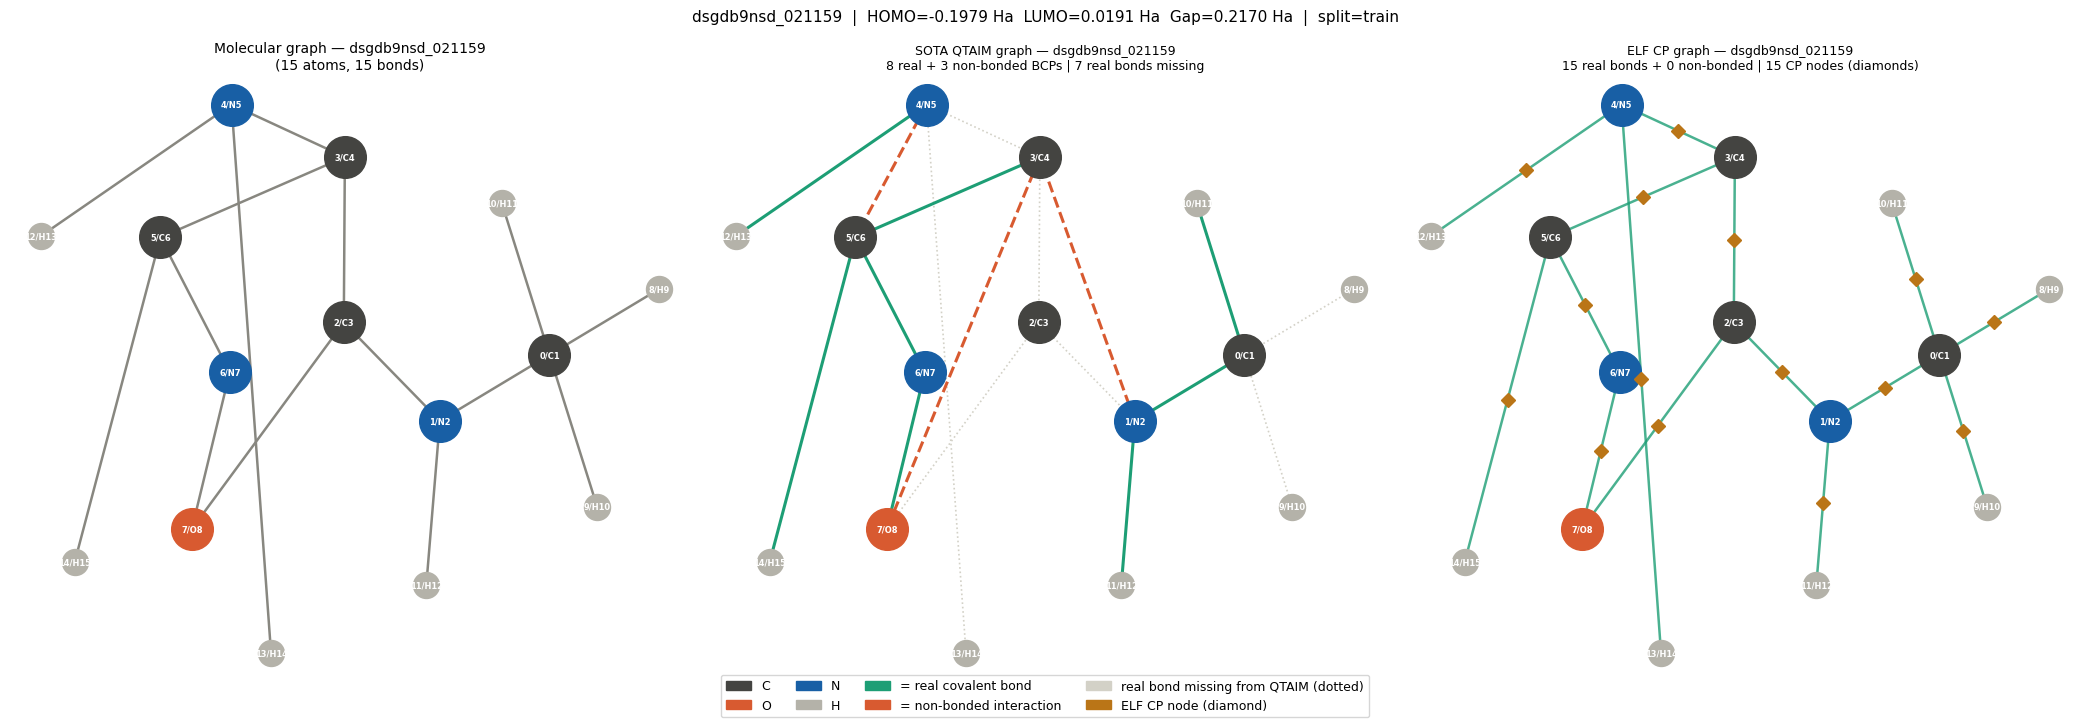

In [9]:
# Draw all three graphs side by side
if data:
    draw_all_three(data)

5.Draw individual graphs, to see in closer look

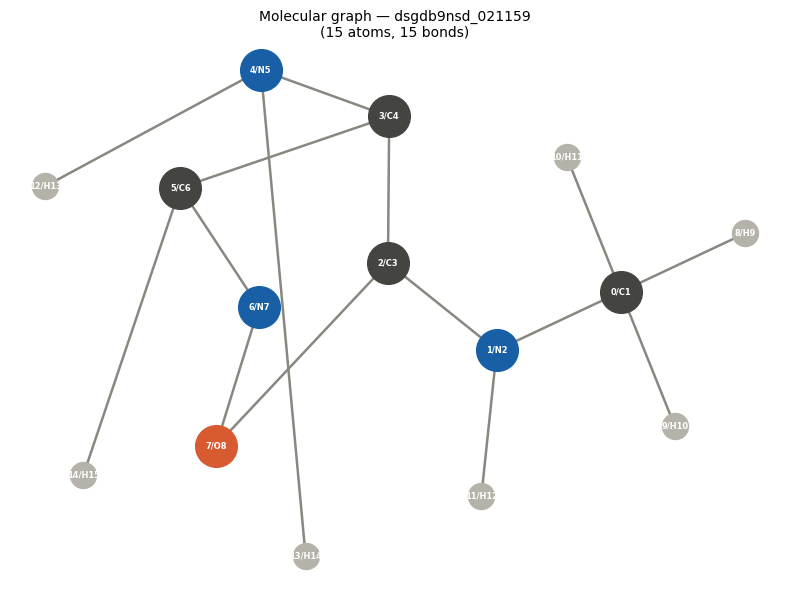

In [10]:
# Individual: molecular graph
if data:
    draw_molecular_graph(data)

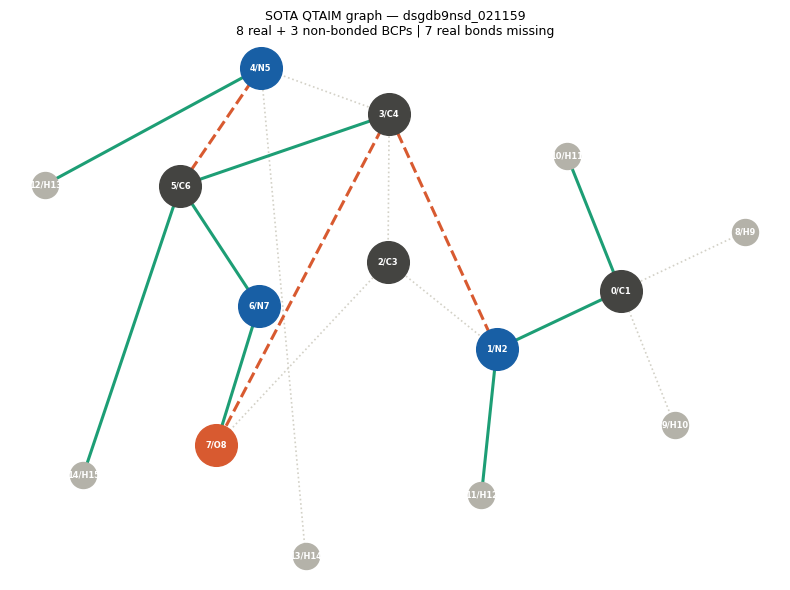

In [11]:
# Individual: QTAIM graph
if data:
    draw_qtaim_graph(data)

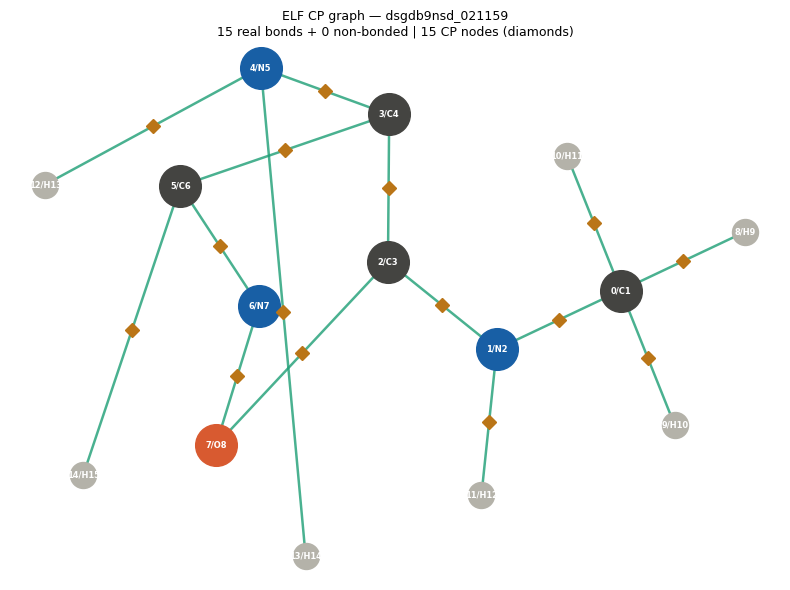

In [12]:
# Individual: ELF CP graph
if data:
    draw_elf_cp_graph(data)

6. Compute multiple molecules

In [ ]:
# Show a few sample molecule IDs from the CSV
print('Sample molecules from ELF CSV:')
sample = elf_df.sample(43000, random_state=42)[['ID','GDB_Index','split','HOMO','LUMO','Gap']]
display(sample)

In [ ]:
# Compare bond coverage across a sample
sample_ids = elf_df.sample(43000, random_state=42)['GDB_Index'].tolist()
rows = []
for gdb in sample_ids:
    d = load_molecule(gdb_index=int(gdb))
    if d is None: continue
    mg    = d['mg_edges']
    qtaim = d['qtaim_edges']
    elf   = d['elf_bond_edges']
    rows.append({
        'mol_id':          d['mol_id'],
        'n_atoms':         d['n_atoms'],
        'real_bonds':      len(mg),
        'qtaim_bonds':     len(qtaim),
        'elf_bonds':       len(elf),
        'qtaim_real':      len([e for e in qtaim if e in mg]),
        'qtaim_nonbond':   len([e for e in qtaim if e not in mg]),
        'qtaim_missing':   len([e for e in mg if e not in qtaim]),
        'elf_coverage':    f"{100*len([e for e in elf if e in mg])/max(len(mg),1):.0f}%",
        'qtaim_coverage':  f"{100*len([e for e in qtaim if e in mg])/max(len(mg),1):.0f}%",
    })

df_cov = pd.DataFrame(rows)
display(df_cov)

# save to CSV
out_csv = f'{BASE}/qtaim_embed_private/tensor_viz/bond_coverage_sample.csv'
df_cov.to_csv(out_csv, index=False)
print(f'✓ Saved: {out_csv}')

In [ ]:
# Save the three-panel figure for the currently loaded molecule
if data:
    outdir = f'{BASE}/qtaim_embed_private/tensor_viz'
    os.makedirs(outdir, exist_ok=True)
    save_path = f'{outdir}/{data["mol_id"]}_three_graphs.png'
    draw_all_three(data, save_path=save_path)